# Developing a machine learning model for predicting length of stay in hospital

In this project, we will develop a machine learning model to predict the length of stay (LOS) for patients in a hospital. The LOS is an important metric for hospital management as it helps in resource allocation and improving patient care.

## Data Collection
We will use a dataset that contains patient information, including demographics, medical history, and hospital stay details. The dataset can be sourced from hospital records or publicly available healthcare datasets.

## Data Preprocessing
1. **Data Cleaning**: Handle missing values, remove duplicates, and correct any inconsistencies in the data.
2. **Feature Engineering**: Create new features that may be relevant for predicting LOS, such as the number of previous hospital visits, severity of illness, and comorbidities.
3. **Encoding Categorical Variables**: Convert categorical variables into numerical format using techniques like one-hot encoding or label encoding.
4. **Feature Scaling**: Normalize or standardize the features to ensure that they are on the same scale, which can improve the performance of certain machine learning algorithms.

## Model Selection
We will experiment with several machine learning algorithms to find the best model for predicting LOS. Some of the algorithms we will consider include:
- Linear Regression
- Decision Trees
- Random Forest 
- Gradient Boosting Machines
- Support Vector Machines

## Model Training and Evaluation
1. **Train-Test Split**: Split the dataset into training and testing sets to evaluate the performance of the model.
2. **Model Training**: Train the selected models on the training data.
3. **Model Evaluation**: Evaluate the models using appropriate metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R²) to assess their performance in predicting LOS.
4. **Hyperparameter Tuning**: Use techniques like Grid Search or Random Search to optimize the hyperparameters of the models for better performance.
5. **Cross-Validation**: Implement cross-validation to ensure that the model's performance is consistent across different subsets of the data.## Model Deployment
Once we have selected the best-performing model, we will deploy it in a production environment. This involves:
1. **Model Serialization**: Save the trained model using a format like Pickle or Joblib for later use.




In [1]:
# libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding libraries
import logging
import miceforest as mf
import pickle
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## ML required libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

In [2]:
data = pd.read_excel('Data/Final_dataset_260126.xlsx')

In [3]:
pd.set_option('display.max_columns', None)
data.head()

,rec_id,date_data_collect,name_of_rrh,patient_id,re_admit,age,sex,res_district,res_subcounty,village,occupation,allergies,infect_site___1,infect_site___2,infect_site___3,infect_site___4,infect_site___5,infect_site___6,infect_site___7,infect_site___8,site_based_sample___1,site_based_sample___2,site_based_sample___3,site_based_sample___4,site_based_sample___5,site_based_sample___6,site_based_sample___7,site_based_sample___8,site_based_sample___9,sec_site_infection___1,sec_site_infection___2,sec_site_infection___3,sec_site_infection___4,sec_site_infection___5,sec_site_infection___6,sec_site_infection___7,sec_site_infection___8,sec_site_infection___9,referral,facility_category,admission_date,ward,antib_prior_admi,prio_antib_name___1,prio_antib_name___2,prio_antib_name___3,prio_antib_name___4,prio_antib_name___5,prio_antib_name___6,prio_antib_name___7,prio_antib_name___8,prio_antib_name___9,prio_antib_name___10,prio_antib_name___11,prio_antib_name___12,prio_antib_name___13,prio_antib_name___14,prio_antib_name___15,prio_antib_name___1617,prio_antib_name___18,prio_antib_name___19,prio_antib_name___20,prio_antib_name___21,prio_antib_name___22,prio_antib_name___23,prio_antib_name___24,prio_antib_name___25,prio_antib_name___26,prio_antib_name___27,prio_antib_name___28,prio_antib_name___29,prio_antib_name___30,prio_antib_name___31,prio_antib_name___32,prio_antib_name___33,prio_antib_name___34,prio_antib_name___35,prio_antib_name___36,prio_antib_name___37,prio_antib_name___38,prio_antib_name___39,prio_antib_name___40,prio_antib_name___41,other_antibiotic_antibiotics_prescribed___42,other_antibiotic_antibiotics_prescribed___43,ref_other,ref_other_antibiotics_prescribed___42,ref_other_antibiotics_prescribed___43,sympt_dura,date_diagn,diag_system___1,diag_system___2,diag_system___3,diag_system___4,diag_system___5,diag_system___6,diag_system___7,diag_system___8,diag_cns,diag_git,diag_resp,diag_genit,diag_musculo,diad_cardio,diag_integu,diag_reprod,hiv_status,indwel_inst___1,indwel_inst___2,indwel_inst___3,indwel_inst___4,indwel_inst___5,indwel_inst___6,indwel_inst___7,indwel_inst___8,indwel_inst___9,oth_indwel,cormobid_condition,cormobidities___1,cormobidities___2,cormobidities___3,cormobidities___4,cormobidities___5,cormobidities___6,cormobidities___7,cormobidities___8,other_comorbidities,antibiotics,antibiotics_prescribed___1,antibiotics_prescribed___2,antibiotics_prescribed___3,antibiotics_prescribed___4,antibiotics_prescribed___5,antibiotics_prescribed___6,antibiotics_prescribed___7,antibiotics_prescribed___8,antibiotics_prescribed___9,antibiotics_prescribed___10,antibiotics_prescribed___11,antibiotics_prescribed___12,antibiotics_prescribed___13,antibiotics_prescribed___14,antibiotics_prescribed___15,antibiotics_prescribed___16,antibiotics_prescribed___17,antibiotics_prescribed___18,antibiotics_prescribed___19,antibiotics_prescribed___20,antibiotics_prescribed___21,antibiotics_prescribed___22,antibiotics_prescribed___23,antibiotics_prescribed___24,antibiotics_prescribed___25,antibiotics_prescribed___26,antibiotics_prescribed___27,antibiotics_prescribed___28,antibiotics_prescribed___29,antibiotics_prescribed___30,antibiotics_prescribed___31,antibiotics_prescribed___32,antibiotics_prescribed___33,antibiotics_prescribed___34,antibiotics_prescribed___35,antibiotics_prescribed___36,antibiotics_prescribed___37,antibiotics_prescribed___38,antibiotics_prescribed___39,antibiotics_prescribed___40,antibiotics_prescribed___41,other_antibiotic,start_date_antib,clin_param___1,clin_param___2,clin_param___3,clin_param___4,clin_param___5,clin_param___6,clin_param___7,bp_type___1,bp_type___2,systolic_bp_baseline,sysbp_samplecoll,disatbp_admit,diastolic_bp_baseline,pulse_baseline,pulse_discharge,temp_baseline,temp_discharge,rr_baseline,rr_discharge,spo2_baseline,spo2_discharge,gcs_baseline,gcs_discharge,culture_and_sensitivity,specimen_type,oth_spectype,collection_date,growth1,organism_isolated,first_organism,ast_anti1___1,ast_anti1___2,ast_anti1___3,ast_an

In [4]:
data.shape

(1913, 851)

# Length of Hospital Stay Calculation

In [5]:
# Calculating the length of hospital stay based on the admission and discharge dates

# Standardise the data types of the date columns
data['admission_date'] = pd.to_datetime(data['admission_date'], errors='coerce')
data['date_at_discharge'] = pd.to_datetime(data['date_at_discharge'], errors='coerce')

# Calculate the length of hospital stay
data['length_hosp_stay'] = (data['date_at_discharge'] - data['admission_date']).dt.days

data['length_hosp_stay'].dtypes

dtype('float64')

In [6]:
pd.set_option('display.max_rows', None)
data.loc[(data['length_hosp_stay'].isna()) & (data['treatment_outcome'] == 'Referred'), ['admission_date', 'treatment_outcome', 'date_death', 'date_at_discharge']]

,admission_date,treatment_outcome,date_death,date_at_discharge
115,2025-02-06,Referred,NaT,NaT
141,2025-09-09,Referred,NaT,NaT
331,2024-07-19,Referred,NaT,NaT
370,2024-07-18,Referred,NaT,NaT
490,2025-06-22,Referred,NaT,NaT
501,2024-07-24,Referred,NaT,NaT
513,2024-10-11,Referred,NaT,NaT
548,2025-05-19,Referred,NaT,NaT
583,2024-09-23,Referred,NaT,NaT
588,2025-02-24,Referred,NaT,NaT


In [7]:
data['length_hosp_stay'].describe()

count    1574.000000
mean       34.587675
std       105.320162
min         0.000000
25%         8.000000
50%        15.000000
75%        31.000000
max      1843.000000
Name: length_hosp_stay, dtype: float64

In [8]:
# Calculate the length of hospital stay for patients who died during their hospital stay
data.loc[data['treatment_outcome'] == 'Died', 'length_hosp_stay'] = (data['date_death'] - data['admission_date']).dt.days

In [9]:
data.loc[data['length_hosp_stay'] < 0, ['length_hosp_stay', 'admission_date', 'date_at_discharge', 'date_death', 'treatment_outcome']]

,length_hosp_stay,admission_date,date_at_discharge,date_death,treatment_outcome
883,-685.0,2024-10-10,NaT,2022-11-25,Died
1024,-727.0,2024-04-30,NaT,2022-05-04,Died


In [10]:
# Fixed: .loc for column names and strings for dates
data.loc[[883, 1024], 'date_death'] = ['2024-11-25', '2024-05-04']
data['date_death'] = pd.to_datetime(data['date_death'], errors='coerce')

In [11]:
# Calculate the length of hospital stay for patients who died during their hospital stay
data.loc[data['treatment_outcome'] == 'Died', 'length_hosp_stay'] = (data['date_death'] - data['admission_date']).dt.days

In [12]:
# Drop rows where length_hosp_stay is still NaN after calculation
data.dropna(subset=['length_hosp_stay'], inplace=True)

# Number of infected sites

In [13]:
infection_sites = [col for col in data.columns if 'infect_site___' in col] 

def count_infection_site(row):
    count = 0
    for col in infection_sites:
        if row[col] == 'Yes':  # Check if the value is not NaN/None
            count += 1
    return count

# Create the new 'Prio_antib' column
data['num_infection_sites'] = data.apply(count_infection_site, axis=1)

# Antibiotics prescribed

In [14]:
antibiotics = [col for col in data.columns if 'antibiotics_prescribed___' in col]

def antibiotics_prescribed(row):
    for col in antibiotics:
        if row[col] == 'Yes':
            return 'Yes'
    return 'No'

data['antibiotics_prescribed'] = data.apply(antibiotics_prescribed, axis=1)

In [15]:
data['antibiotics_prescribed'].value_counts()

antibiotics_prescribed
Yes    1314
No      450
Name: count, dtype: int64

In [16]:
data['ward'].unique()

array(['Gynaecology', 'Orthopaedic', 'Paediatric', 'Surgical',
       'Maternity/Post-Natal ward', 'TB ward', 'Medical', 'ICU/HDU',
       'Accident and emergency', 'NICU Unit', 'Private wing',
       'Maternity/ Post-Natal ward'], dtype=object)

In [17]:
ward_dict = {
    'Maternity/ Post-Natal ward' : 'Maternity/Post-Natal ward',
}

data['ward'].replace(ward_dict, inplace = True)

# Resistance

In [18]:
res_cols = [col for col in data.columns if 'first' or 'sec' or 'third' in col]

def res_checker (row):res_cols = [col for col in data.columns if 'first' or 'sec' or 'third' in col]

def res_checker (row):
    for col in res_cols:
        if row[col] == 'Resistant':
            return 'Yes'
    return 'No'

data['Resistance'] = data.apply(res_checker, axis = 1)

In [19]:
data['Resistance'].value_counts()

Resistance
No     967
Yes    797
Name: count, dtype: int64

# ML dataset

In [20]:
# select the features that had been identified as important in the previous step

features = ['name_of_rrh', 'age', 'sex', 'num_infection_sites', 'referral',
       'ward','cormobid_condition', 'antibiotics_prescribed',
       'growth1', 'Resistance', 'length_hosp_stay']

ml_data = data[features]

In [21]:
ml_data.head()

,name_of_rrh,age,sex,num_infection_sites,referral,ward,cormobid_condition,antibiotics_prescribed,growth1,Resistance,length_hosp_stay
0,Arua,36.0,Female,2,No,Gynaecology,No,Yes,No,No,13.0
1,Arua,57.0,Female,3,No,Orthopaedic,No,Yes,Yes,Yes,46.0
2,Arua,8.0,Female,2,No,Gynaecology,No,Yes,Yes,Yes,1.0
3,Arua,1.0,Male,3,Yes,Paediatric,No,Yes,No,No,4.0
4,Arua,21.0,Female,1,Yes,Gynaecology,No,Yes,Yes,Yes,3.0


In [22]:
ml_data.isna().sum()

name_of_rrh               0
age                       2
sex                       0
num_infection_sites       0
referral                  1
ward                      0
cormobid_condition        0
antibiotics_prescribed    0
growth1                   5
Resistance                0
length_hosp_stay          0
dtype: int64

# impute for missingness

In [23]:
## growth

ml_data['growth1'] = ml_data['growth1'].fillna('No')

/tmp/ipykernel_21585/3026064413.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_data['growth1'] = ml_data['growth1'].fillna('No')


In [24]:
##  Referral

ml_data['referral'] = ml_data['referral'].fillna('No')

/tmp/ipykernel_21585/278076231.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_data['referral'] = ml_data['referral'].fillna('No')


## MICE Age imputation

In [25]:
# Convert object columns to category (miceforest cannot model object dtype)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

def run_mice_imputation(
    data,
    output_folder: str = "mice_results",
    num_datasets: int = 5,
    num_iterations: int = 5,
    random_state: int = 42,
    save_kernel: bool = True,
):
    os.makedirs(output_folder, exist_ok=True)
    logger.info("Output folder ready: '%s'", output_folder)

    data = data.reset_index(drop=True)

    # Convert object columns to category
    obj_cols = data.select_dtypes(include="object").columns.tolist()
    logger.info("Converting %d object columns to category: %s", len(obj_cols), obj_cols)
    data[obj_cols] = data[obj_cols].astype("category")

    logger.info("Initialising ImputationKernel — num_datasets=%d, iterations=%d, seed=%d",
                num_datasets, num_iterations, random_state)

    kernel = mf.ImputationKernel(
        data=data,
        num_datasets=num_datasets,
        save_all_iterations_data=True,
        random_state=random_state,
    )
    kernel.mice(iterations=num_iterations)
    logger.info("MICE training complete.")

    for i in range(kernel.num_datasets):
        df_imputed = kernel.complete_data(dataset=i)
        file_path = os.path.join(output_folder, f"imputed_data_{i}.csv")
        df_imputed.to_csv(file_path, index=False)
        logger.info("Saved dataset %d → %s  (shape: %s)", i, file_path, df_imputed.shape)

    if save_kernel:
        kernel_path = os.path.join(output_folder, "trained_imputer.pkl")
        with open(kernel_path, "wb") as f:
            pickle.dump(kernel, f)
        logger.info("Kernel saved → %s", kernel_path)

    return kernel

# ── Run ────────────────────────────────────────────────────────────
kernel = run_mice_imputation(
    data=ml_data,
    output_folder="mice_results",
    num_datasets=5,
    num_iterations=5,
    random_state=42,
)

2026-03-22 14:37:10,285 - INFO - Output folder ready: 'mice_results'
2026-03-22 14:37:10,289 - INFO - Converting 8 object columns to category: ['name_of_rrh', 'sex', 'referral', 'ward', 'cormobid_condition', 'antibiotics_prescribed', 'growth1', 'Resistance']
2026-03-22 14:37:10,301 - INFO - Initialising ImputationKernel — num_datasets=5, iterations=5, seed=42
2026-03-22 14:37:38,165 - INFO - MICE training complete.
2026-03-22 14:37:38,183 - INFO - Saved dataset 0 → mice_results/imputed_data_0.csv  (shape: (1764, 11))
2026-03-22 14:37:38,195 - INFO - Saved dataset 1 → mice_results/imputed_data_1.csv  (shape: (1764, 11))
2026-03-22 14:37:38,206 - INFO - Saved dataset 2 → mice_results/imputed_data_2.csv  (shape: (1764, 11))
2026-03-22 14:37:38,216 - INFO - Saved dataset 3 → mice_results/imputed_data_3.csv  (shape: (1764, 11))
2026-03-22 14:37:38,226 - INFO - Saved dataset 4 → mice_results/imputed_data_4.csv  (shape: (1764, 11))
2026-03-22 14:37:38,358 - INFO - Kernel saved → mice_results/

# Data transformations

In [26]:
path = r'/home/kyomukama/ACE/camonet/ML_Rerun/' 
os.chdir(path)
print(f"Current Directory: {os.getcwd()}")

Current Directory: /home/kyomukama/ACE/camonet/ML_Rerun


In [27]:
imputed_data = pd.read_csv("/home/kyomukama/ACE/camonet/ML_Rerun/mice_results/imputed_data_0.csv")

In [28]:
imputed_data.head()

,name_of_rrh,age,sex,num_infection_sites,referral,ward,cormobid_condition,antibiotics_prescribed,growth1,Resistance,length_hosp_stay
0,Arua,36.0,Female,2,No,Gynaecology,No,Yes,No,No,13.0
1,Arua,57.0,Female,3,No,Orthopaedic,No,Yes,Yes,Yes,46.0
2,Arua,8.0,Female,2,No,Gynaecology,No,Yes,Yes,Yes,1.0
3,Arua,1.0,Male,3,Yes,Paediatric,No,Yes,No,No,4.0
4,Arua,21.0,Female,1,Yes,Gynaecology,No,Yes,Yes,Yes,3.0


In [29]:
X = imputed_data.drop(columns=['length_hosp_stay'])
y = imputed_data['length_hosp_stay']

In [30]:
y.dtypes

dtype('float64')

In [31]:
X.dtypes

name_of_rrh                object
age                       float64
sex                        object
num_infection_sites         int64
referral                   object
ward                       object
cormobid_condition         object
antibiotics_prescribed     object
growth1                    object
Resistance                 object
dtype: object

In [32]:
cat_columns = X.select_dtypes(include='object').columns
cat_columns

Index(['name_of_rrh', 'sex', 'referral', 'ward', 'cormobid_condition',
       'antibiotics_prescribed', 'growth1', 'Resistance'],
      dtype='object')

In [33]:
def build_encoding_pipeline(data, obj_cols=None, threshold=10):
    """
    Builds and fits a sklearn Pipeline that:
    - One-Hot encodes low cardinality columns  (nunique <= threshold)
    - Ordinal encodes high cardinality columns (nunique >  threshold)
    - Passes numeric columns through untouched

    Args:
        data:       Input DataFrame.
        obj_cols:   Columns to encode. If None, auto-detects object/category cols.
        threshold:  Max unique values for One-Hot encoding (default 10).

    Returns:
        pipeline:       Fitted sklearn Pipeline.
        df_transformed: Transformed DataFrame with readable column names.
        feature_names:  List of output column names (reuse when transforming test data).
    """
    df = data.copy()

    if obj_cols is None:
        obj_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    low_card  = [col for col in obj_cols if df[col].nunique() <= threshold]
    high_card = [col for col in obj_cols if df[col].nunique() >  threshold]
    num_cols  = df.select_dtypes(include=["number"]).columns.tolist()

    print(f"Numeric columns  ({len(num_cols)}):  {num_cols}")
    print(f"One-Hot encoded  ({len(low_card)}):  {low_card}")
    print(f"Ordinal encoded  ({len(high_card)}): {high_card}")

    # ----------------------------------------------------------------
    # Build ColumnTransformer
    # ----------------------------------------------------------------
    transformers = []

    if num_cols:
        transformers.append(("numeric", "passthrough", num_cols))

    if low_card:
        transformers.append((
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_card,
        ))

    if high_card:
        transformers.append((
            "ordinal",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            high_card,
        ))

    col_transformer = ColumnTransformer(transformers=transformers, remainder="drop")

    # Pipeline
    pipeline = Pipeline(steps=[
        ("encoding", col_transformer)
    ])

    # ----------------------------------------------------------------
    # Fit & transform
    # ----------------------------------------------------------------
    transformed_array = pipeline.fit_transform(df)

    # ----------------------------------------------------------------
    # Rebuild readable column names
    # ----------------------------------------------------------------
    feature_names = list(num_cols)

    if low_card:
        ohe = pipeline.named_steps["encoding"].named_transformers_["onehot"]
        feature_names += ohe.get_feature_names_out(low_card).tolist()

    if high_card:
        feature_names += high_card

    df_transformed = pd.DataFrame(transformed_array, columns=feature_names, index=df.index)

    return pipeline, df_transformed, feature_names


# ──────────────────────────────────────────────────────────────
pipeline, X_transformed, feature_names = build_encoding_pipeline(X, threshold=2)
X_transformed.head()

Numeric columns  (2):  ['age', 'num_infection_sites']
One-Hot encoded  (6):  ['sex', 'referral', 'cormobid_condition', 'antibiotics_prescribed', 'growth1', 'Resistance']
Ordinal encoded  (2): ['name_of_rrh', 'ward']


,age,num_infection_sites,sex_Male,referral_Yes,cormobid_condition_Yes,antibiotics_prescribed_Yes,growth1_Yes,Resistance_Yes,name_of_rrh,ward
0,36.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,57.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,6.0
2,8.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
3,1.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,7.0
4,21.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0


In [34]:
# rename columns
columns = ['sex', 'referral', 'cormobid_condition', 'antibiotics_prescribed', 'growth1', 'Resistance']

old_cols = ['sex_Male', 'referral_Yes','cormobid_condition_Yes', 'antibiotics_prescribed_Yes', 'growth1_Yes', 'Resistance_Yes']

# Creating the mapping dictionary
rename_dict = dict(zip(old_cols, columns))

# Applying rename to the DataFrame
X_transformed.rename(columns=rename_dict, inplace=True)

X_transformed.head()

,age,num_infection_sites,sex,referral,cormobid_condition,antibiotics_prescribed,growth1,Resistance,name_of_rrh,ward
0,36.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,57.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,6.0
2,8.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
3,1.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,7.0
4,21.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0


In [35]:
X.head

<bound method NDFrame.head of      name_of_rrh    age     sex  num_infection_sites referral  \
0           Arua   36.0  Female                    2       No   
1           Arua   57.0  Female                    3       No   
2           Arua    8.0  Female                    2       No   
3           Arua    1.0    Male                    3      Yes   
4           Arua   21.0  Female                    1      Yes   
5           Arua    0.0    Male                    3       No   
6           Arua    9.0    Male                    1       No   
7           Arua    1.0    Male                    2      Yes   
8           Arua   54.0  Female                    1       No   
9           Arua   80.0  Female                    1       No   
10          Arua   42.0    Male                    1       No   
11          Arua   33.0  Female                    4      Yes   
12          Arua    4.0  Female                    1       No   
13          Arua   54.0    Male                    1       N

# Correct datatypes of the different columns

In [36]:
X_transformed.dtypes

age                       float64
num_infection_sites       float64
sex                       float64
referral                  float64
cormobid_condition        float64
antibiotics_prescribed    float64
growth1                   float64
Resistance                float64
name_of_rrh               float64
ward                      float64
dtype: object

In [37]:
# Converting object columns 'category'
cols = ['sex', 'referral', 'cormobid_condition', 'antibiotics_prescribed', 'growth1', 'Resistance']
X_transformed[cols] = X_transformed[cols].astype('category')


In [38]:
train_wards = set(X_transformed["ward"].unique())
train_wards

{0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0}

# Test set

In [39]:
# import the test set
test_set = pd.read_csv('/home/kyomukama/ACE/camonet/ml (NEW)/ML clinical outcomes data 14.02.25 version 2  - new.csv')
test_set.head()

,name_of_rrh,age,sex,Number of sites infected,referral,ward,antib_prior_admi,sympt_dura,hiv_status,intubated,cormobid_condition,antibiotics,Number of antibiotics prescribed,organism_isolated,growth1,Resistance,antib_aft_culture,length_hosp_stay
0,Arua,6.0,Male,1,Yes,Pediatric ward,Unknown,< 1 week,Unknown,Unknown,No,Yes,1,0,No,No,No,12
1,Arua,13.0,Male,2,Yes,Medical ward,Unknown,1- < 2 weeks,Negative,Unknown,No,No,0,0,No,No,No,8
2,Arua,11.0,Male,1,No,Pediatric ward,Unknown,< 1 week,Unknown,Unknown,Yes,Yes,2,0,No,No,No,14
3,Arua,18.0,Male,1,Yes,Surgical ward,Unknown,< 1 week,Unknown,Unknown,No,Yes,2,1,Yes,Yes,No,0
4,Arua,17.0,Female,1,Yes,Maternity ward,Unknown,< 1 week,Positive,Unknown,Yes,Yes,3,1,Yes,Yes,Yes,10


In [40]:
test_set['ward'].value_counts()

ward
Surgical ward      224
Medical ward       133
Pediatric ward      91
Maternity ward      55
Gyecology ward      34
ICU Unit            27
NICU                23
Orthopedic ward      3
HDU                  3
Private wing         2
Urology ward         1
Name: count, dtype: int64

In [41]:
# dict

ward_dict = {
    'Pediatric ward': 'Paediatric',
    "Surgical ward" : 'Surgical',
    "Medical ward" : 'Medical',
    "Maternity ward" : 'Maternity/Post-Natal ward',
    "Gyecology ward" : 'Gynaecology',
    "ICU Unit" : 'ICU/HDU',
    "NICU" : "NICU Unit"
}

test_set['ward'].replace(ward_dict, inplace = True)

In [42]:
test_set.isna().sum()

name_of_rrh                         0
age                                 1
sex                                 0
Number of sites infected            0
referral                            0
ward                                0
antib_prior_admi                    0
sympt_dura                          0
hiv_status                          0
intubated                           0
cormobid_condition                  0
antibiotics                         7
Number of antibiotics prescribed    0
organism_isolated                   0
growth1                             0
Resistance                          0
antib_aft_culture                   0
length_hosp_stay                    0
dtype: int64

In [43]:
test_set['age'] = test_set['age'].fillna(test_set['age'].mean())

In [44]:
def antibiotics_pres(row):

    if row['Number of sites infected'] > 0:
        return 'Yes'
    else:
        return 'No'

test_set['antibiotics_prescribed']  = test_set.apply(antibiotics_pres, axis = 1)

In [45]:
test_set.columns

Index(['name_of_rrh', 'age', 'sex', 'Number of sites infected', 'referral',
       'ward', 'antib_prior_admi', 'sympt_dura', 'hiv_status', 'intubated',
       'cormobid_condition', 'antibiotics', 'Number of antibiotics prescribed',
       'organism_isolated', 'growth1', 'Resistance', 'antib_aft_culture',
       'length_hosp_stay', 'antibiotics_prescribed'],
      dtype='object')

In [46]:
columns = [
    'name_of_rrh', 'age', 'sex', 
    'Number of sites infected', 
    'referral','ward', 'cormobid_condition',  
    'growth1', 'Resistance',
    'length_hosp_stay', 'antibiotics_prescribed']

test_set = test_set[columns]

In [47]:
test_set.rename(columns={'Number of sites infected': 'num_infection_sites'}, inplace = True)
test_set.head()

,name_of_rrh,age,sex,num_infection_sites,referral,ward,cormobid_condition,growth1,Resistance,length_hosp_stay,antibiotics_prescribed
0,Arua,6.0,Male,1,Yes,Paediatric,No,No,No,12,Yes
1,Arua,13.0,Male,2,Yes,Medical,No,No,No,8,Yes
2,Arua,11.0,Male,1,No,Paediatric,Yes,No,No,14,Yes
3,Arua,18.0,Male,1,Yes,Surgical,No,Yes,Yes,0,Yes
4,Arua,17.0,Female,1,Yes,Maternity/Post-Natal ward,Yes,Yes,Yes,10,Yes


In [48]:
X_transformed.shape

(1764, 10)

In [49]:
X_test = test_set.drop(columns = ['length_hosp_stay'])
y_test = test_set['length_hosp_stay']

In [50]:
# Transforming test data using the fitted pipeline
X_test_transformed = pd.DataFrame(
    pipeline.transform(X_test),
    columns=feature_names
)

X_test_transformed.head()

,age,num_infection_sites,sex_Male,referral_Yes,cormobid_condition_Yes,antibiotics_prescribed_Yes,growth1_Yes,Resistance_Yes,name_of_rrh,ward
0,6.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,7.0
1,13.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,4.0
2,11.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,7.0
3,18.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,9.0
4,17.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0


In [51]:
test_wards  = set(X_test_transformed["ward"].unique())
test_wards

{-1.0, 1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 8.0, 9.0}

In [52]:
# rename columns
columns = ['sex', 'referral', 'cormobid_condition', 'antibiotics_prescribed', 'growth1', 'Resistance']

old_cols = ['sex_Male', 'referral_Yes','cormobid_condition_Yes', 'antibiotics_prescribed_Yes', 'growth1_Yes', 'Resistance_Yes']

# Creating the mapping dictionary
rename_dict = dict(zip(old_cols, columns))

# Applying rename to the DataFrame
X_test_transformed.rename(columns=rename_dict, inplace=True)

X_test_transformed.head()

,age,num_infection_sites,sex,referral,cormobid_condition,antibiotics_prescribed,growth1,Resistance,name_of_rrh,ward
0,6.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,7.0
1,13.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,4.0
2,11.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,7.0
3,18.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,9.0
4,17.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0


In [53]:
# Converting object columns 'category'
cols = ['sex', 'referral', 'cormobid_condition', 'antibiotics_prescribed', 'growth1', 'Resistance']
X_test_transformed[cols] = X_test_transformed[cols].astype('category')

In [54]:
X_test_transformed.dtypes

age                        float64
num_infection_sites        float64
sex                       category
referral                  category
cormobid_condition        category
antibiotics_prescribed    category
growth1                   category
Resistance                category
name_of_rrh                float64
ward                       float64
dtype: object

In [55]:
y  = np.log1p(y)
y_test   = np.log1p(y_test)

Target distribution:
  Mean   : 2.82
  Median : 2.77
  Std    : 1.03
  Min    : 0.00
  Max    : 7.52
  Skew   : 0.54

Train vs Test target distribution:
  Train mean : 2.82  |  Test mean : 2.66
  Train std  : 1.03   |  Test std  : 0.96


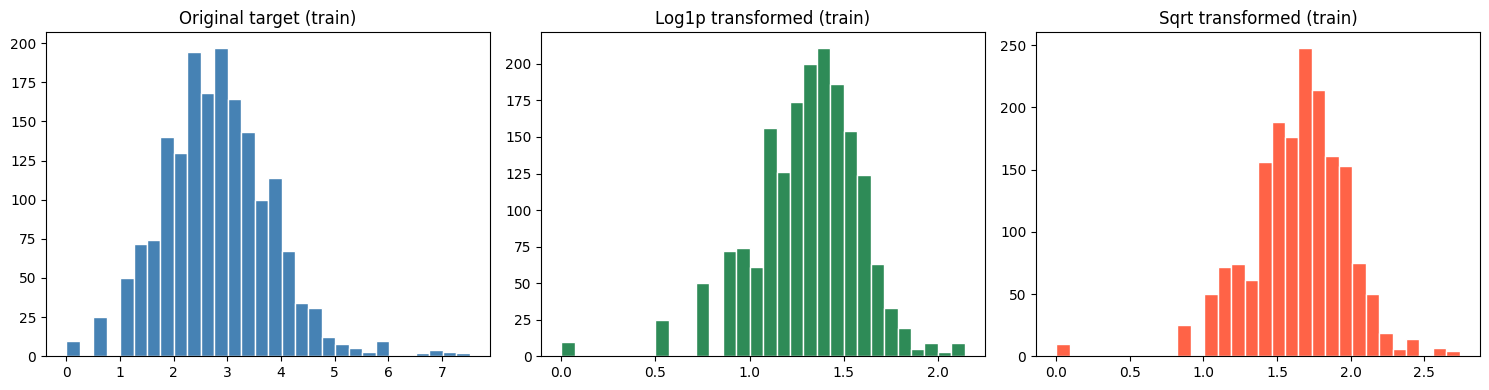


XGBoost CV RMSE (log scale) : 0.275 ± 0.020

XGBoost Test Results (original scale):
  RMSE : 0.922
  MAE  : 0.735
  R²   : 0.079


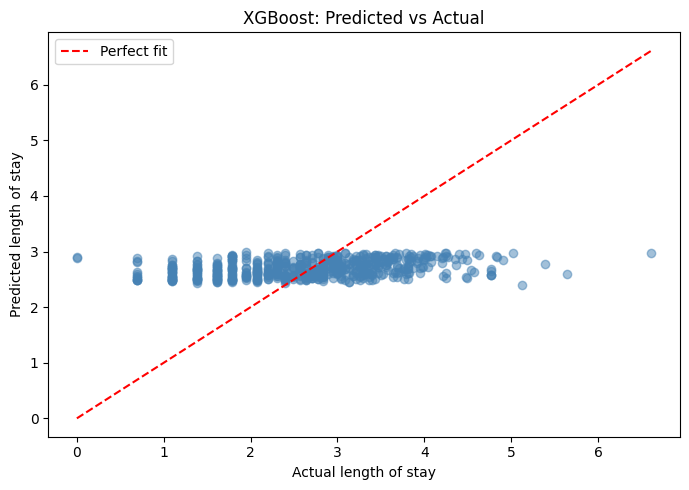

In [56]:
from scipy import stats

# ── 1. Diagnose target distribution ───────────────────────────────
print("Target distribution:")
print(f"  Mean   : {y.mean():.2f}")
print(f"  Median : {y.median():.2f}")
print(f"  Std    : {y.std():.2f}")
print(f"  Min    : {y.min():.2f}")
print(f"  Max    : {y.max():.2f}")
print(f"  Skew   : {y.skew():.2f}")

print("\nTrain vs Test target distribution:")
print(f"  Train mean : {y.mean():.2f}  |  Test mean : {y_test.mean():.2f}")
print(f"  Train std  : {y.std():.2f}   |  Test std  : {y_test.std():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(y,             bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Original target (train)")
axes[1].hist(np.log1p(y),   bins=30, color="seagreen",  edgecolor="white")
axes[1].set_title("Log1p transformed (train)")
axes[2].hist(np.sqrt(y),    bins=30, color="tomato",    edgecolor="white")
axes[2].set_title("Sqrt transformed (train)")
plt.tight_layout()
plt.show()

# ── 2. Apply log1p transformation to target ────────────────────────
y_train_log  = np.log1p(y)
y_test_log   = np.log1p(y_test)

# ── 3. Rerun best model (XGBoost) with transformed target ──────────
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_params = {
    "colsample_bytree": 0.5,
    "learning_rate":    0.01,
    "max_depth":        3,
    "n_estimators":     100,
    "reg_alpha":        0.1,
    "reg_lambda":       0.5,
    "subsample":        0.5,
    "enable_categorical": True,
    "random_state":     42,
    "eval_metric":      "rmse",
}

xgb_model = XGBRegressor(**best_params)

# CV on log-transformed target
cv_rmse = np.sqrt(-cross_val_score(
    xgb_model, X_transformed, y_train_log,
    cv=kf, scoring="neg_mean_squared_error"
))
print(f"\nXGBoost CV RMSE (log scale) : {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

# Fit and predict
xgb_model.fit(X_transformed, y_train_log)
preds_log = xgb_model.predict(X_test_transformed)

# Inverse transform predictions back to original scale
preds_original = np.expm1(preds_log)

# Evaluate on original scale
rmse = np.sqrt(mean_squared_error(y_test, preds_original))
mae  = mean_absolute_error(y_test, preds_original)
r2   = r2_score(y_test, preds_original)

print(f"\nXGBoost Test Results (original scale):")
print(f"  RMSE : {rmse:.3f}")
print(f"  MAE  : {mae:.3f}")
print(f"  R²   : {r2:.3f}")

# ── 4. Visual check: predicted vs actual ──────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(y_test, preds_original, alpha=0.5, color="steelblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", label="Perfect fit")
plt.xlabel("Actual length of stay")
plt.ylabel("Predicted length of stay")
plt.title("XGBoost: Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

# ML

In [57]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200, 
        random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.05, 
        random_state=42),

    "XGBoost": XGBRegressor(
        enable_categorical=True,
        n_estimators=200, 
        learning_rate=0.05, 
        random_state=42, 
        eval_metric='rmse'),

    "LightGBM": LGBMRegressor(
        n_estimators=200, 
        learning_rate=0.05, 
        random_state=42)
}

In [58]:
results = []

for name, model in models.items():
    model.fit(X_transformed, y)
    preds = model.predict(X_test_transformed)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results.append([name, mse, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "MAE", "R2"])
print(results_df)

               Model       MSE      RMSE       MAE        R2
0      Random Forest  1.022053  1.010966  0.789577 -0.106865
1  Gradient Boosting  0.916243  0.957206  0.750836  0.007725
2            XGBoost  0.959980  0.979786  0.768060 -0.039641
3           LightGBM  0.986636  0.993296  0.778995 -0.068509


In [59]:
best_model_name = results_df.sort_values("RMSE").iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: Gradient Boosting


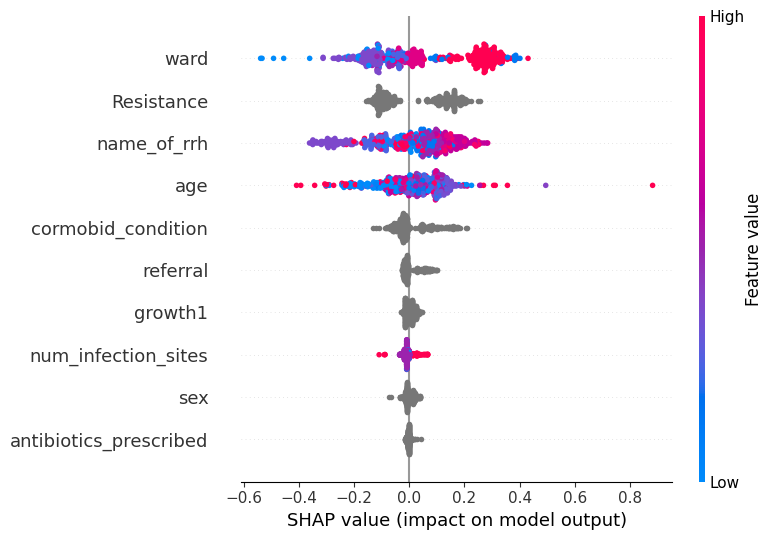

                  feature  importance
9                    ward    0.165879
7              Resistance    0.118783
8             name_of_rrh    0.115369
0                     age    0.089039
4      cormobid_condition    0.043717
3                referral    0.025366
6                 growth1    0.013734
1     num_infection_sites    0.013442
2                     sex    0.011859
5  antibiotics_prescribed    0.004479


In [60]:
explainer = shap.Explainer(best_model, X_transformed)
shap_values = explainer(X_test_transformed)

# Summary plot
shap.summary_plot(shap_values, X_test_transformed)

# Feature importance table
feature_importance = pd.DataFrame({
    "feature": X_test_transformed.columns,
    "importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values("importance", ascending=False)

print(feature_importance.head(10))

In [61]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV


# ── 1. Cross-validation helper ─────────────────────────────────────
def cross_validate_model(name, model, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error"))
    mae_scores  = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")
    r2_scores   =  cross_val_score(model, X, y, cv=kf, scoring="r2")
    print(f"{name:<20} CV RMSE: {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f} | "
          f"MAE: {mae_scores.mean():.3f} | R²: {r2_scores.mean():.3f}")
    return rmse_scores.mean()

# ── 2. Hyperparameter grids ────────────────────────────────────────
param_grids = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators":      [100, 200, 300],
            "max_depth":         [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf":  [1, 2, 4],
            "max_features":      ["sqrt", "log2"],
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators":  [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth":     [3, 5, 7],
            "subsample":     [0.7, 0.8, 1.0],
            "min_samples_leaf": [1, 2, 4],
        }
    },
    "XGBoost": {
        "model": XGBRegressor(enable_categorical=True, random_state=42, eval_metric="rmse"),
        "params": {
            "n_estimators":  [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth":     [3, 5, 7],
            "subsample":     [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0],
            "reg_alpha":     [0, 0.1, 1.0],   # L1
            "reg_lambda":    [1, 1.5, 2.0],   # L2
        }
    },
    "LightGBM": {
        "model": LGBMRegressor(random_state=42, verbose=-1),
        "params": {
            "n_estimators":   [100, 200, 300],
            "learning_rate":  [0.01, 0.05, 0.1],
            "max_depth":      [-1, 5, 10],
            "num_leaves":     [31, 50, 100],
            "subsample":      [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0],
            "reg_alpha":      [0, 0.1, 1.0],
            "reg_lambda":     [0, 0.1, 1.0],
        }
    },
}

# ── 3. Baseline cross-validation (before tuning) ───────────────────
print("=" * 60)
print("BASELINE CROSS-VALIDATION (default params)")
print("=" * 60)
baseline_models = {
    "Random Forest":    RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting":GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    "XGBoost":          XGBRegressor(enable_categorical=True, n_estimators=200, learning_rate=0.05, random_state=42),
    "LightGBM":         LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
}
for name, model in baseline_models.items():
    cross_validate_model(name, model, X_transformed, y)

# ── 4. Hyperparameter tuning with RandomizedSearchCV ──────────────
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING (RandomizedSearchCV)")
print("=" * 60)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
tuned_models = {}
results = []

for name, config in param_grids.items():
    print(f"\nTuning {name}...")
    search = RandomizedSearchCV(
        estimator  = config["model"],
        param_distributions = config["params"],
        n_iter     = 30,          # increase for better search, slower runtime
        cv         = kf,
        scoring    = "neg_root_mean_squared_error",
        n_jobs     = -1,
        random_state = 42,
        verbose    = 0,
    )
    search.fit(X_transformed, y)

    best_model = search.best_estimator_
    tuned_models[name] = best_model

    # Evaluate on test set
    preds = best_model.predict(X_test_transformed)
    mse   = mean_squared_error(y_test, preds)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)

    print(f"  Best params : {search.best_params_}")
    print(f"  CV RMSE     : {-search.best_score_:.3f}")
    print(f"  Test RMSE   : {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

    results.append([name, -search.best_score_, rmse, mae, r2])

# ── 5. Summary table ───────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
results_df = pd.DataFrame(results, columns=["Model", "CV RMSE", "Test RMSE", "MAE", "R2"])
results_df = results_df.sort_values("Test RMSE").reset_index(drop=True)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
best_model      = tuned_models[best_model_name]
print(f"\nBest model: {best_model_name}")

BASELINE CROSS-VALIDATION (default params)
Random Forest        CV RMSE: 1.037 ± 0.053 | MAE: 0.787 | R²: -0.022
Gradient Boosting    CV RMSE: 0.981 ± 0.044 | MAE: 0.747 | R²: 0.084
XGBoost              CV RMSE: 1.033 ± 0.046 | MAE: 0.786 | R²: -0.016
LightGBM             CV RMSE: 1.029 ± 0.036 | MAE: 0.784 | R²: -0.008

HYPERPARAMETER TUNING (RandomizedSearchCV)

Tuning Random Forest...
  Best params : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}
  CV RMSE     : 0.982
  Test RMSE   : 0.927 | MAE: 0.730 | R²: 0.068

Tuning Gradient Boosting...
  Best params : {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.05}
  CV RMSE     : 0.977
  Test RMSE   : 0.942 | MAE: 0.739 | R²: 0.039

Tuning XGBoost...
  Best params : {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  CV RMSE     : 0.975


In [62]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

# ── 1. Cross-validation helper ─────────────────────────────────────
def cross_validate_model(name, model, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error"))
    mae_scores  = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")
    r2_scores   =  cross_val_score(model, X, y, cv=kf, scoring="r2")
    print(f"{name:<20} CV RMSE: {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f} | "
          f"MAE: {mae_scores.mean():.3f} | R²: {r2_scores.mean():.3f}")
    return rmse_scores.mean()

# ── 2. Hyperparameter grids ────────────────────────────────────────
# NOTE: GridSearch tests EVERY combination — keep grids small to avoid
# very long runtimes. Expand values once you know the promising range.
param_grids = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators":      [100, 200],
            "max_depth":         [None, 10, 20],
            "min_samples_split": [2, 5],
            "min_samples_leaf":  [1, 2],
            "max_features":      ["sqrt", "log2"],
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators":     [100, 200],
            "learning_rate":    [0.05, 0.1],
            "max_depth":        [3, 5],
            "subsample":        [0.8, 1.0],
            "min_samples_leaf": [1, 2],
        }
    },
    "XGBoost": {
        "model": XGBRegressor(enable_categorical=True, random_state=42, eval_metric="rmse"),
        "params" : {
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [100, 500, 1000],
            'subsample': [0.5, 0.75, 1.0],
            'colsample_bytree': [0.5, 0.75, 1.0],
            'reg_alpha': [0, 0.1, 0.5],
            'reg_lambda': [0, 0.1, 0.5]
        }
    },
    "LightGBM": {
        "model": LGBMRegressor(random_state=42, verbose=-1),
        "params": {
            "n_estimators":     [100, 200],
            "learning_rate":    [0.05, 0.1],
            "max_depth":        [-1, 10],
            "num_leaves":       [31, 50],
            "subsample":        [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "reg_alpha":        [0, 0.1],
            "reg_lambda":       [0, 0.1],
        }
    },
}

# ── 3. Baseline cross-validation (before tuning) ───────────────────
print("=" * 60)
print("BASELINE CROSS-VALIDATION (default params)")
print("=" * 60)
baseline_models = {
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    "XGBoost":           XGBRegressor(enable_categorical=True, n_estimators=200, learning_rate=0.05, random_state=42),
    "LightGBM":          LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
}
for name, model in baseline_models.items():
    cross_validate_model(name, model, X_transformed, y)

# ── 4. GridSearchCV tuning ─────────────────────────────────────────
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING (GridSearchCV)")
print("=" * 60)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
tuned_models = {}
results      = []

for name, config in param_grids.items():
    print(f"\nTuning {name}...")

    # Estimate number of fits
    from itertools import product
    n_combos = len(list(product(*config["params"].values())))
    print(f"  Grid size: {n_combos} combinations × 5 folds = {n_combos * 5} fits")

    search = GridSearchCV(
        estimator  = config["model"],
        param_grid = config["params"],
        cv         = kf,
        scoring    = "neg_root_mean_squared_error",
        n_jobs     = -1,
        verbose    = 1,
    )
    search.fit(X_transformed, y)

    best_model        = search.best_estimator_
    tuned_models[name] = best_model

    # Evaluate on test set
    preds = best_model.predict(X_test_transformed)
    mse   = mean_squared_error(y_test, preds)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)

    print(f"  Best params : {search.best_params_}")
    print(f"  CV RMSE     : {-search.best_score_:.3f}")
    print(f"  Test RMSE   : {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

    results.append([name, -search.best_score_, rmse, mae, r2])

# ── 5. Summary table ───────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
results_df = pd.DataFrame(results, columns=["Model", "CV RMSE", "Test RMSE", "MAE", "R2"])
results_df = results_df.sort_values("Test RMSE").reset_index(drop=True)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
best_model      = tuned_models[best_model_name]
print(f"\nBest model: {best_model_name}")

BASELINE CROSS-VALIDATION (default params)
Random Forest        CV RMSE: 1.037 ± 0.053 | MAE: 0.787 | R²: -0.022
Gradient Boosting    CV RMSE: 0.981 ± 0.044 | MAE: 0.747 | R²: 0.084
XGBoost              CV RMSE: 1.033 ± 0.046 | MAE: 0.786 | R²: -0.016
LightGBM             CV RMSE: 1.029 ± 0.036 | MAE: 0.784 | R²: -0.008

HYPERPARAMETER TUNING (GridSearchCV)

Tuning Random Forest...
  Grid size: 48 combinations × 5 folds = 240 fits
Fitting 5 folds for each of 48 candidates, totalling 240 fits
  Best params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
  CV RMSE     : 0.984
  Test RMSE   : 0.936 | MAE: 0.735 | R²: 0.052

Tuning Gradient Boosting...
  Grid size: 32 combinations × 5 folds = 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
  Best params : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100, 'subsample': 0.8}
  CV RMSE     : 0.977
  Test RMSE   : 0.942 | MAE